Project 1: Exploratory Data Analysis (EDA) on Retail Sales Dataset

In [6]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the Dataset
df = pd.read_csv("retail_sales_dataset.csv")

In [14]:
# Display First 5 Rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [15]:
# Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [16]:
# Statistical Summary
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [17]:
# Check Missing Values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [18]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [19]:
# Display Column Names
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

1. Sales by Product Category

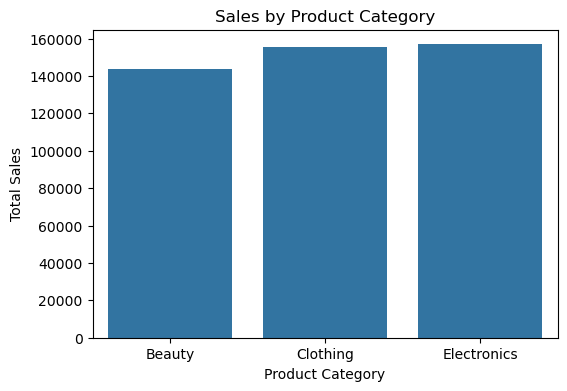

In [20]:
# Sales by Product Category

category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

2. Sales by Gender

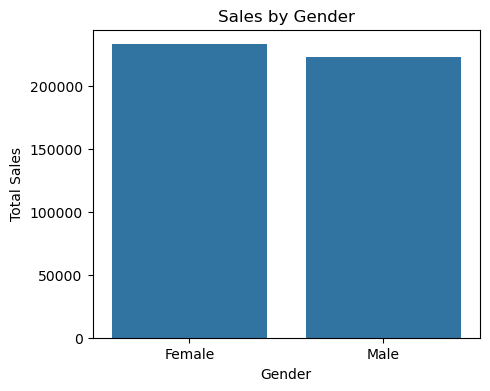

In [21]:
# Sales by Gender

gender_sales = df.groupby("Gender")["Total Amount"].sum()

plt.figure(figsize=(5,4))
sns.barplot(x=gender_sales.index, y=gender_sales.values)

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

3. Age Distribution

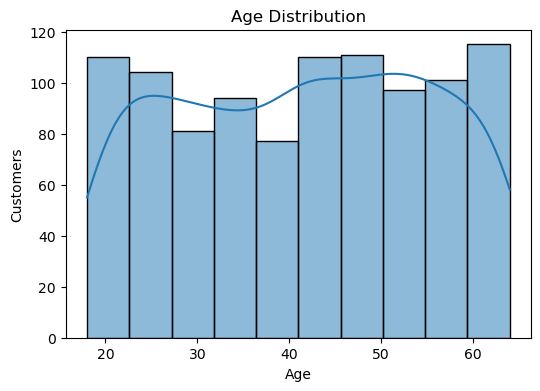

In [22]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.show()

4. Monthly Sales Trend

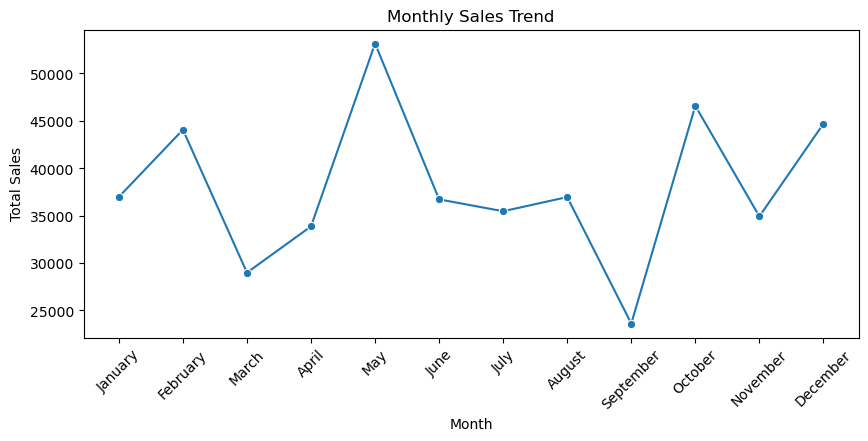

In [23]:
# Monthly Sales Trend

df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.month_name())["Total Amount"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,4))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

5. Quantity Sold by Product Category

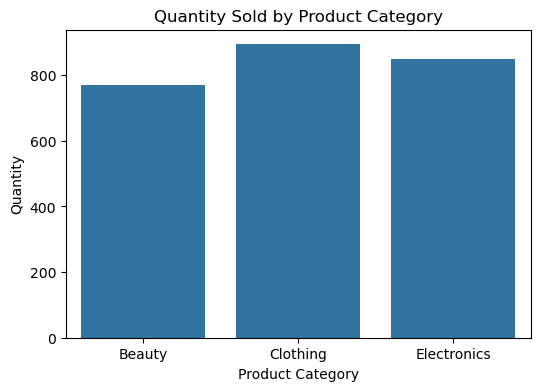

In [24]:
# Quantity Sold by Product Category

quantity = df.groupby("Product Category")["Quantity"].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=quantity.index, y=quantity.values)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")

plt.show()

6. Price Distribution

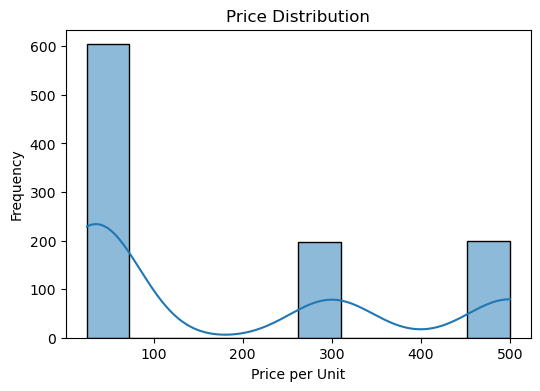

In [25]:
# Price Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Price per Unit"], bins=10, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")

plt.show()

7. Correlation Heatmap

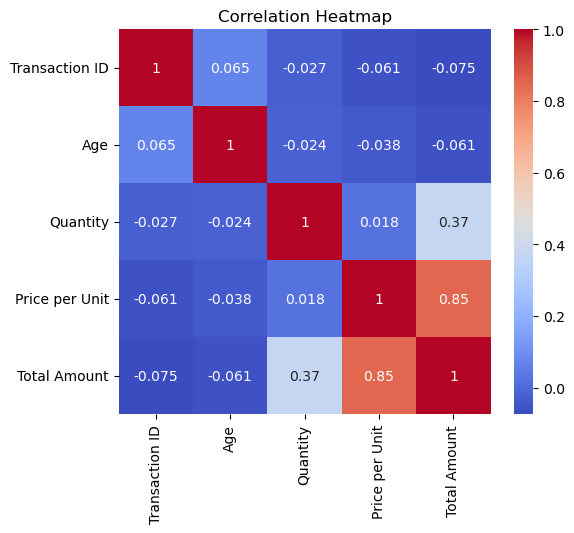

In [26]:
# Correlation Heatmap

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

8. Top 10 Highest Sales Transactions

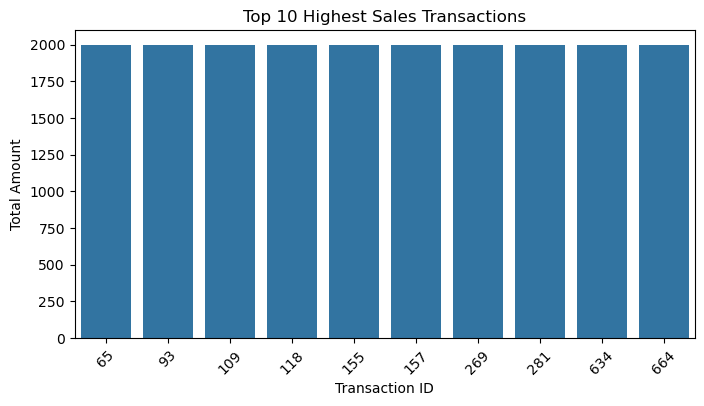

In [27]:
# Top 10 Highest Sales Transactions

top_sales = df.sort_values("Total Amount", ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(data=top_sales, x="Transaction ID", y="Total Amount")

plt.title("Top 10 Highest Sales Transactions")
plt.xticks(rotation=45)

plt.show()

## Conclusion

- The dataset contains 1000 retail sales records.
- No missing values or duplicate records were found.
- Sales vary across product categories and months.
- Customer age and gender provide useful business insights.
- The dataset is clean and suitable for analysis.